# 04 — What text should the critic read?

The LightGBM critic reached **PR-AUC 0.982** on the frozen test set. Logistic
regression on the same features reached **0.944**. Two points of separation
between the simplest model and a tuned one means the feature table is close to
exhausted — no further model will squeeze much more out of counting joins and
errors.

The features describe the SQL. They never read it. `sql_length=200, sql_joins=3`
is true of both a correct query and one that joins the wrong two tables.

So the question for this notebook is not "which model" but **"which text"**.
Getting that wrong wastes every GPU hour that follows.

**What this notebook decides, and hands to `scripts/train_bert.py`:**

1. Which fields go into the string
2. How long the sequence needs to be
3. Whether there is signal in the text at all — measured cheaply, on CPU,
   before committing to fine-tuning

**What it does not do:** train anything. Fine-tuning is 20–40 minutes per run
on a 6 GB card and belongs in a script, not a cell whose kernel dies when the
laptop sleeps.

## 1. Load — the same table and the same frozen split as the feature critic

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from agent.critic.text import FORMATS, add_text_column, build_text

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

df = pd.read_parquet(ROOT / "data" / "critic" / "labelled_steps.parquet")
split = json.loads((ROOT / "data" / "critic" / "split.json").read_text())

print(f"{len(df):,} steps from {df.run_id.nunique():,} runs")
print(f"split: {len(split['test_runs'])} test runs, seed {split['seed']}")
print(f"note:  {split['note']}")

5,461 steps from 1,620 runs
split: 302 test runs, seed 23
note:  frozen — regenerating invalidates comparisons across versions


### The target, and why it is `y_run_fails`

Not `label_step`. That column is assigned by rules in `agent/labeller.py` that
read the step's own fields — **92.6% of it is reproducible from the model's own
inputs**, so training on it mostly relearns an `if` statement and scores
beautifully while predicting nothing.

`y_run_fails` comes from executing the gold SQL and comparing result sets.
Nothing in the step's text can produce it.

In [2]:
df = df[df.y_run_fails.notna()].copy()
df["y"] = df.y_run_fails.astype(int)

is_test = df.run_id.isin(set(split["test_runs"]))
train_df, test_df = df[~is_test].copy(), df[is_test].copy()

# The split is grouped by run_id: every step of a run lands on the same side.
# Steps within a run are near-duplicates — same question, same schema, often
# the same query retried — so splitting by step would put the answer on both
# sides of the boundary.
overlap = set(train_df.run_id) & set(test_df.run_id)
assert not overlap, f"run_id leak across the split: {len(overlap)} runs"

print(f"train {len(train_df):>6,} steps   {train_df.run_id.nunique():>5,} runs   "
      f"base rate {train_df.y.mean():.3f}")
print(f"test  {len(test_df):>6,} steps   {test_df.run_id.nunique():>5,} runs   "
      f"base rate {test_df.y.mean():.3f}")
print("\nno run_id appears on both sides")

train  4,197 steps   1,210 runs   base rate 0.782
test   1,030 steps     302 runs   base rate 0.817

no run_id appears on both sides


## 2. Read some actual steps

Before choosing an input format, look at what is there. If a person cannot
separate these by eye, a 150M-parameter model on 4,000 examples probably
cannot either — and that is worth knowing now rather than after training.

In [3]:
def show(row, n=340):
    print(f"  question : {row.question}")
    print(f"  thought  : {str(row.thought)[:n]}")
    print(f"  tool     : {row.tool}")
    print(f"  sql      : {str(row.sql)[:n] if row.sql else '(none)'}")
    if row.obs_error:
        print(f"  error    : {row.obs_error}")
    print(f"  -> run {'FAILED' if row.y else 'SUCCEEDED'}")

rng = np.random.default_rng(23)

print("=" * 78)
print("STEPS FROM RUNS THAT SUCCEEDED")
print("=" * 78)
for _, r in train_df[train_df.y == 0].sample(3, random_state=23).iterrows():
    show(r); print("-" * 78)

print()
print("=" * 78)
print("STEPS FROM RUNS THAT FAILED")
print("=" * 78)
for _, r in train_df[train_df.y == 1].sample(3, random_state=23).iterrows():
    show(r); print("-" * 78)

STEPS FROM RUNS THAT SUCCEEDED
  question : What are the names of instructors who didn't teach?
  thought  : I need to find instructors who are not listed in the teaches table.
  tool     : run_sql
  sql      : SELECT DISTINCT name FROM instructor EXCEPT SELECT DISTINCT i.name FROM instructor AS i JOIN teaches AS t ON i.ID = t.ID
  error    : nan
  -> run SUCCEEDED
------------------------------------------------------------------------------
  question : What are the drivers' first, last names and id who had more than 8 pit stops or participated in more than 5 race results?
  thought  : I need to identify drivers with multiple pit stops or race results.
  tool     : run_sql
  sql      : SELECT driverId FROM pitStops GROUP BY driverId HAVING COUNT(*) > 8 UNION SELECT driverId FROM results GROUP BY driverId HAVING COUNT(*) > 5
  error    : nan
  -> run SUCCEEDED
------------------------------------------------------------------------------
  question : Count the number of distinct instr

**What to look for.** The failing steps should show something the feature table
cannot see — a query that runs cleanly but answers a different question, a join
on the wrong key, an aggregate over the wrong column. If the only visible
difference is "this one errored", the features already capture it via
`is_error` and there is nothing for BERT to add.

## 3. Four candidate formats

Each adds exactly one thing to the previous, so any difference in score is
attributable:

| format | contains |
|---|---|
| `sql` | the query alone |
| `qsql` | + the user's question |
| `full` | + the model's stated reasoning |
| `full_err` | + the error message, when present |

Defined in `agent/critic/text.py` so the notebook and the training script build
strings identically — a mismatch there is the classic train/serve skew bug, and
it fails silently.

In [4]:
ex = train_df.iloc[7]
for fmt in FORMATS:
    s = build_text(ex, fmt)
    print(f"--- {fmt}  ({len(s)} chars) " + "-" * (52 - len(fmt)))
    print(s[:400])
    print()

--- sql  (56 chars) -------------------------------------------------
SELECT MAX(COUNT(raceId)) FROM results GROUP BY driverId

--- qsql  (160 chars) ------------------------------------------------
question: What are the ids and last names of all drivers who participated in the most races? [SEP] sql: SELECT MAX(COUNT(raceId)) FROM results GROUP BY driverId

--- full  (398 chars) ------------------------------------------------
question: What are the ids and last names of all drivers who participated in the most races? [SEP] thought: To find the drivers who participated in the most races, I need to first determine the maximum number of races any driver has participated in and then retrieve the IDs and last names of all drivers who have that many races. [SEP] sql: SELECT MAX(COUNT(raceId)) FROM results GROUP BY driverId

--- full_err  (448 chars) --------------------------------------------
question: What are the ids and last names of all drivers who participated in the most races? [SEP

## 4. How long do the sequences actually need to be?

In [5]:
from transformers import AutoTokenizer

MODEL = "answerdotai/ModernBERT-base"
try:
    tok = AutoTokenizer.from_pretrained(MODEL)
except Exception as e:
    print(f"{MODEL} unavailable ({type(e).__name__}), falling back to bert-base-uncased")
    MODEL = "bert-base-uncased"
    tok = AutoTokenizer.from_pretrained(MODEL)

print(f"tokenizer: {MODEL}\n")

lengths = {}
sample = train_df.sample(min(1500, len(train_df)), random_state=23)
for fmt in FORMATS:
    texts = [build_text(r, fmt) for _, r in sample.iterrows()]
    lengths[fmt] = np.array([len(tok(t)["input_ids"]) for t in texts])

rows = []
for fmt, L in lengths.items():
    rows.append({"format": fmt, "mean": L.mean(), "p50": np.percentile(L, 50),
                 "p95": np.percentile(L, 95), "p99": np.percentile(L, 99),
                 "max": L.max(),
                 "% over 256": 100 * (L > 256).mean()})
print(pd.DataFrame(rows).round(1).to_string(index=False))

c:\dev\project23\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\dev\project23\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\punit\.cache\huggingface\hub\models--answerdotai--ModernBERT-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this

tokenizer: answerdotai/ModernBERT-base

  format  mean  p50   p95   p99  max  % over 256
     sql  35.9 26.0  86.0 118.0  136         0.0
    qsql  58.3 48.0 113.0 144.0  163         0.0
    full  83.5 74.0 143.0 172.0  192         0.0
full_err  85.4 75.0 152.0 182.0  203         0.0


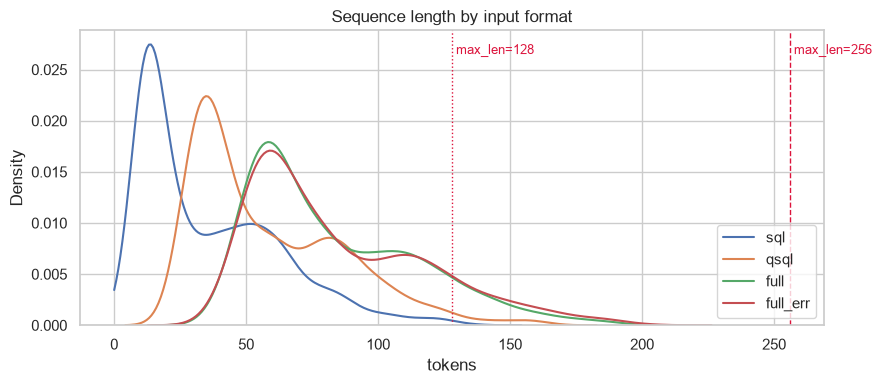

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for fmt, L in lengths.items():
    sns.kdeplot(L, ax=ax, label=fmt, fill=False, clip=(0, None))
for x, style in [(128, ":"), (256, "--")]:
    ax.axvline(x, color="crimson", ls=style, lw=1)
    ax.text(x, ax.get_ylim()[1] * 0.92, f" max_len={x}", color="crimson", fontsize=9)
ax.set_xlabel("tokens"); ax.set_title("Sequence length by input format")
ax.legend(); plt.tight_layout(); plt.show()

**Why this matters more than it looks.** Attention cost grows with the square of
sequence length, and VRAM with it. On a 6 GB card that is the difference between
a batch size of 8 and 32, and between a 40-minute run and a 12-minute one.

Pick the smallest `max_len` that keeps the p99 intact. Truncating the tail of a
long SQL query removes exactly the clause — the `WHERE`, the `GROUP BY` — most
likely to be what went wrong.

## 5. Is there signal in the text at all?

This is the cell that decides whether the rest is worth doing.

TF-IDF over character n-grams plus logistic regression: no GPU, about ten
seconds, no fine-tuning. It reads the text as bags of character sequences, so
it catches `GROUP BY` and table names but understands nothing.

Read it as a **floor**, not a prediction of what BERT will do. If a bag of
character n-grams already beats the 0.982 feature model, the text is rich and
fine-tuning is clearly worth it. If it lands far below, the text may still carry
signal that only a model with actual language understanding can reach — but the
case is weaker and worth knowing before spending the GPU hours.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline

groups = train_df.run_id.values
y = train_df.y.values
gkf = GroupKFold(n_splits=5)

proxy = {}
for fmt in FORMATS:
    X = np.array([build_text(r, fmt) for _, r in train_df.iterrows()])
    scores = []
    for tr, va in gkf.split(X, y, groups):
        pipe = make_pipeline(
            TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                            min_df=3, max_features=50_000, sublinear_tf=True),
            LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced"),
        )
        pipe.fit(X[tr], y[tr])
        scores.append(average_precision_score(y[va], pipe.predict_proba(X[va])[:, 1]))
    proxy[fmt] = (np.mean(scores), np.std(scores))
    print(f"  {fmt:<10} PR-AUC {np.mean(scores):.4f} ± {np.std(scores):.4f}")

print(f"\n  {'base rate':<10} PR-AUC {y.mean():.4f}")
print(f"  {'features':<10} PR-AUC 0.9626   (LightGBM, cross-validated)")

  sql        PR-AUC 0.9422 ± 0.0064
  qsql       PR-AUC 0.9580 ± 0.0066
  full       PR-AUC 0.9586 ± 0.0073
  full_err   PR-AUC 0.9598 ± 0.0070

  base rate  PR-AUC 0.7825
  features   PR-AUC 0.9626   (LightGBM, cross-validated)


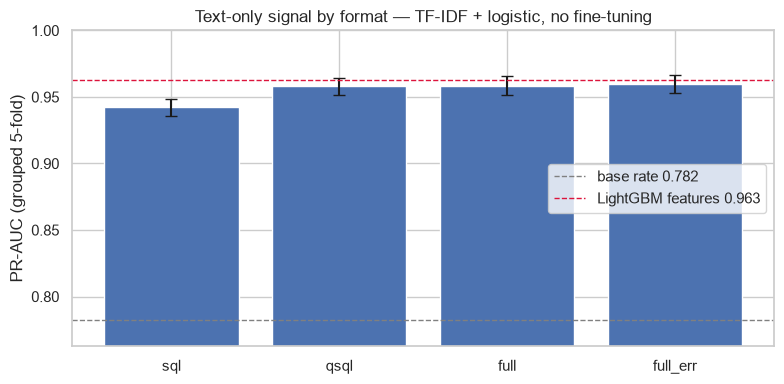

strongest format on the cheap proxy: full_err  (0.9598)


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(proxy)
means = [proxy[f][0] for f in names]
errs = [proxy[f][1] for f in names]
ax.bar(names, means, yerr=errs, capsize=4, color="#4C72B0")
ax.axhline(y.mean(), color="grey", ls="--", lw=1, label=f"base rate {y.mean():.3f}")
ax.axhline(0.9626, color="crimson", ls="--", lw=1, label="LightGBM features 0.963")
ax.set_ylim(min(min(means) - 0.05, y.mean() - 0.02), 1.0)
ax.set_ylabel("PR-AUC (grouped 5-fold)")
ax.set_title("Text-only signal by format — TF-IDF + logistic, no fine-tuning")
ax.legend(); plt.tight_layout(); plt.show()

best = max(proxy, key=lambda f: proxy[f][0])
print(f"strongest format on the cheap proxy: {best}  ({proxy[best][0]:.4f})")

### Reading the result honestly

Three cases, and they lead to different decisions:

**The proxy beats 0.963.** The text carries more than the features do, and
fine-tuning should extend that. Proceed.

**The proxy is close to 0.963.** Both views are describing the same underlying
thing. The interesting experiment becomes *combining* them, not replacing one
with the other.

**The proxy is well below 0.963.** Character n-grams find little. That is not
proof BERT will fail — the whole point of a pretrained model is understanding
that n-grams cannot reach — but it lowers the prior, and the honest move is to
say so in the write-up rather than after.

One caveat in all three cases: TF-IDF can win for the wrong reason. If failing
runs happen to mention certain table names more often, it learns the table names
and not the reasoning. Section 6 checks for that.

## 6. What is the proxy actually keying on?

Before trusting the number above, look at which n-grams drive it. If the top
features are SQL structure (`GROUP BY`, `JOIN`, `COUNT(`) that is real signal.
If they are dataset-specific table names, it has memorised which *questions* are
hard rather than which *steps* are bad — which will not generalise to the
`chinook_1` holdout, and certainly not to a user's own database.

In [9]:
X = np.array([build_text(r, best) for _, r in train_df.iterrows()])
vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3,
                      max_features=50_000, sublinear_tf=True)
Xv = vec.fit_transform(X)
lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xv, y)

names = np.array(vec.get_feature_names_out())
coef = lr.coef_[0]
top_fail = names[np.argsort(coef)[-20:]][::-1]
top_ok = names[np.argsort(coef)[:20]]

print(f"format: {best}\n")
print("n-grams pushing towards FAILURE:")
print("   " + "  ".join(repr(s) for s in top_fail))
print("\nn-grams pushing towards SUCCESS:")
print("   " + "  ".join(repr(s) for s in top_ok))

format: full_err

n-grams pushing towards FAILURE:
   'id '  ' no '  'there'  ' ther'  'err'  'e) '  ' no'  'umn'  'olu'  'lum'  'lumn'  'olumn'  'olum'  'colum'  ' col'  'col'  'colu'  ' colu'  ' as '  'non'

n-grams pushing towards SUCCESS:
   ' 201'  '201'  '2017'  '017'  ' 2017'  'y? '  ' 20'  'es.'  ' 50'  'dent?'  ' hav'  'hav'  'ist'  ' how '  ' man'  'isors'  'sors'  'man'  'answe'  'answ'


## 7. Decision

Fill this in from what the cells above actually showed, then run the training
script with these settings. Writing it down here is what makes the next notebook
a comparison rather than a guess.

In [10]:
DECISION = {
    "format":   best,          # from section 5
    "max_len":  256,           # from section 4 — smallest that keeps p99 intact
    "model":    MODEL,
    "target":   "y_run_fails",
    "proxy_pr_auc":    round(float(proxy[best][0]), 4),
    "features_pr_auc": 0.9626,
    "base_rate":       round(float(y.mean()), 4),
}

out = ROOT / "data" / "critic" / "text_config.json"
out.write_text(json.dumps(DECISION, indent=2))
print(json.dumps(DECISION, indent=2))
print(f"\n-> {out}")
print("\nNext:")
print(f"  python scripts/train_bert.py --format {DECISION['format']} "
      f"--max-len {DECISION['max_len']}")

{
  "format": "full_err",
  "max_len": 256,
  "model": "answerdotai/ModernBERT-base",
  "target": "y_run_fails",
  "proxy_pr_auc": 0.9598,
  "features_pr_auc": 0.9626,
  "base_rate": 0.7825
}

-> c:\dev\project23\data\critic\text_config.json

Next:
  python scripts/train_bert.py --format full_err --max-len 256


---

## What happens next

`scripts/train_bert.py` reads `text_config.json`, so the training run cannot
silently disagree with the decision made here.

**Stop Ollama before training.** It holds the GPU, and 6 GB will not host both a
3B language model and a fine-tuning run. The symptom is a CUDA out-of-memory
error that looks like a bug in the code. The script checks for this and refuses
to start rather than failing halfway through epoch two.

Then `05_critic_comparison.ipynb` scores the result on the same frozen test set
and puts its PR curve on the same axes as LightGBM's 0.982 — along with the
latency comparison, which is where a 150M-parameter model has to justify itself
against 3.35 ms per step.